# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [1]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm_notebook
from sklearn.manifold import TSNE

import shutil

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

from sklearn.model_selection import train_test_split

%matplotlib inline

In [2]:
import time
from datetime import timedelta

notebook_start_time = time.time()

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [4]:
import kagglehub
import shutil
import os

PATH = 'kaggle'

os.makedirs(PATH, exist_ok=True)

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [5]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

if os.path.exists(images_path):
    for item in os.listdir(images_path):
        src = os.path.join(images_path, item)
        dst = os.path.join(PATH, item)
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)

In [6]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")

if os.path.exists(attrs_path):
    for item in os.listdir(attrs_path):
        src = os.path.join(attrs_path, item)
        dst = os.path.join(PATH, item)
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)

In [7]:
# DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
# ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

DATASET_PATH = "kaggle/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "kaggle/lfw_attributes.txt"

In [8]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id, 'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [9]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [10]:
RANDOM_SEED = 42

X_train, X_val, attrs_train, attrs_val = train_test_split(
    images, attrs, test_size=0.15, random_state=RANDOM_SEED
)

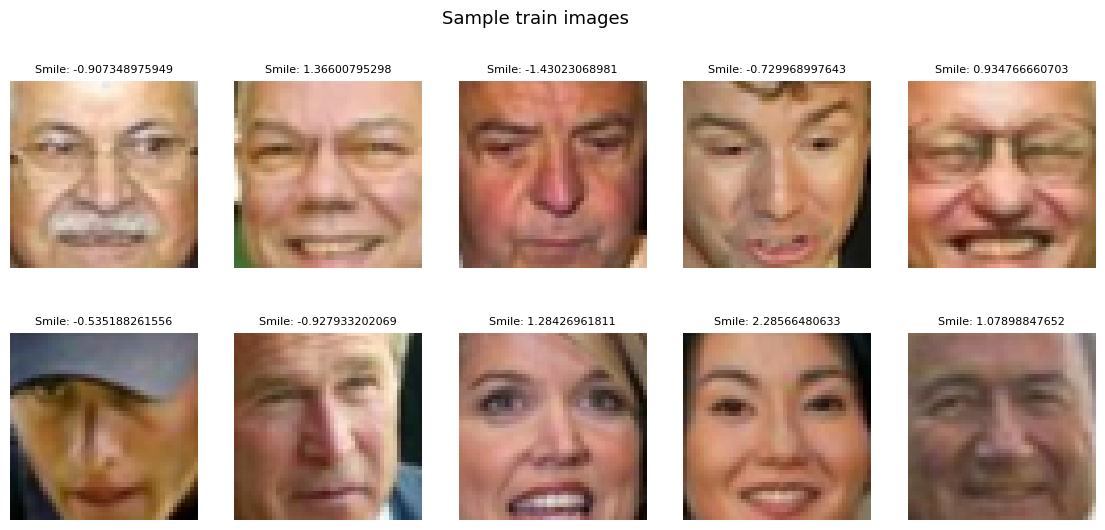

In [11]:
# Визуализация (посмотрим на аттрибут Smiling)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(f"Smile: {attrs_train.iloc[i]['Smiling']}", fontsize=8)
    ax.axis('off')
plt.suptitle('Sample train images', fontsize=13)

plt.show();

In [12]:
def to_tensor(imgs: np.ndarray) -> torch.FloatTensor:
    return torch.tensor(imgs, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0

X_train_t = to_tensor(X_train)
X_val_t = to_tensor(X_val)

BATCH_SIZE = 64
train_dataset = data_utils.TensorDataset(X_train_t)
val_dataset = data_utils.TensorDataset(X_val_t)
train_loader = data_utils.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = data_utils.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train tensor:   {X_train_t.shape}')
print(f'Val tensor:     {X_val_t.shape}')

Train tensor:   torch.Size([11171, 3, 45, 45])
Val tensor:     torch.Size([1972, 3, 45, 45])


## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.


In [13]:
dim_code = 256
IMG_SHAPE = (3, 45, 45)
INPUT_DIM = 3 * 45 * 45

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [14]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, dim_code=dim_code):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, dim_code), 
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(dim_code, 128 * 6 * 6), nn.ReLU(),
            nn.Unflatten(1, (128, 6, 6)),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=0), 
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=0), 
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        
        return reconstruction, latent_code

In [15]:
criterion = nn.MSELoss()

autoencoder = Autoencoder().to(device)

optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

In [16]:
EPOCHS = 5
train_losses, val_losses = [], []
VIZ_N = 8
viz_imgs = X_val_t[:VIZ_N].to(device)

Epoch  1/5 | Train Loss: 0.0238 | Val Loss: 0.0120
Epoch  2/5 | Train Loss: 0.0091 | Val Loss: 0.0078
Epoch  3/5 | Train Loss: 0.0070 | Val Loss: 0.0064
Epoch  4/5 | Train Loss: 0.0059 | Val Loss: 0.0057
Epoch  5/5 | Train Loss: 0.0053 | Val Loss: 0.0051


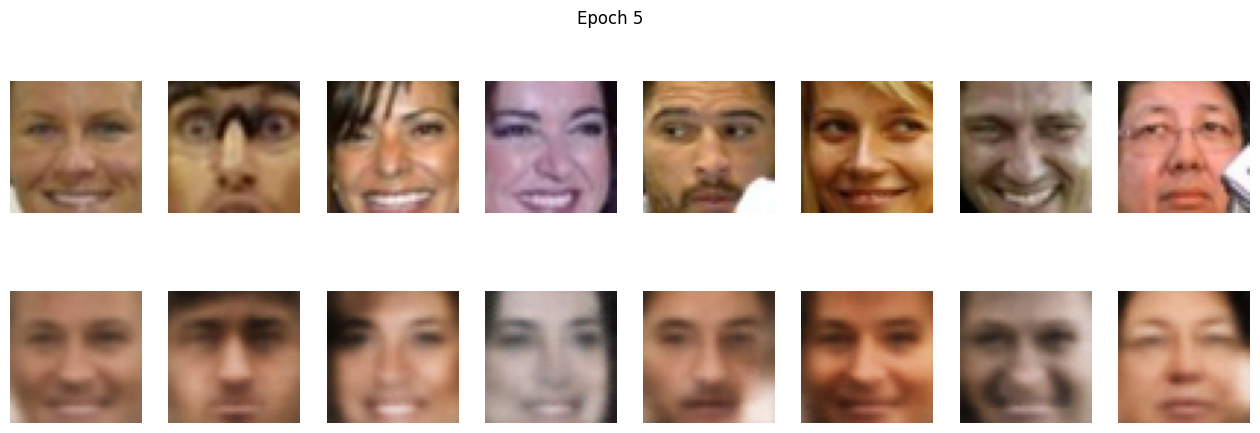

In [17]:
for epoch in range(1, EPOCHS + 1):
    autoencoder.train()
    running_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, _ = autoencoder(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    autoencoder.eval()
    with torch.no_grad():
        val_loss = sum(criterion(autoencoder(b.to(device))[0], b.to(device)).item() for (b,) in val_loader) / len(val_loader)
    val_losses.append(val_loss)

    print(f'Epoch {epoch:>2}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f}')

    if epoch % 5 == 0:
        with torch.no_grad():
            recons, _ = autoencoder(viz_imgs)
        fig, axes = plt.subplots(2, VIZ_N, figsize=(VIZ_N * 2, 5))
        for i in range(VIZ_N):
            axes[0, i].imshow(viz_imgs[i].cpu().permute(1, 2, 0))
            axes[0, i].axis('off')
            axes[1, i].imshow(recons[i].cpu().permute(1, 2, 0))
            axes[1, i].axis('off')
        plt.suptitle(f'Epoch {epoch}') 
        plt.show()

Что вы можете сказать про результат?

Модель обучается стабильно, лосс (MSE) снижается, переобучения не наблюдается. Во всех случаях реконструкции получаются удовлетворительными: лица остаются узнаваемыми, сохраняется общая структура (положение глаз, носа, контуры), освещение и крупные детали (например, зубы при улыбке).
Основным недостатком является размытость изображений, что связано с использованием MSE Loss, который штрафует модель за резкие отклонения и заставляет ее выдавать «усредненный» безопасный результат. В одном из случаев (Код 2) также были отмечены небольшие артефакты, качество которых улучшалось при увеличении размерности скрытого пространства (latent code), но ценой более долгого обучения.

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [18]:
autoencoder.eval()

# Собираем статистику латентного пространства
all_latents = []
with torch.no_grad():
    for batch in train_loader:
        _, z = autoencoder(batch[0].to(device))
        all_latents.append(z.cpu().numpy())
all_latents = np.concatenate(all_latents)
mu, sigma = all_latents.mean(axis=0), all_latents.std(axis=0)

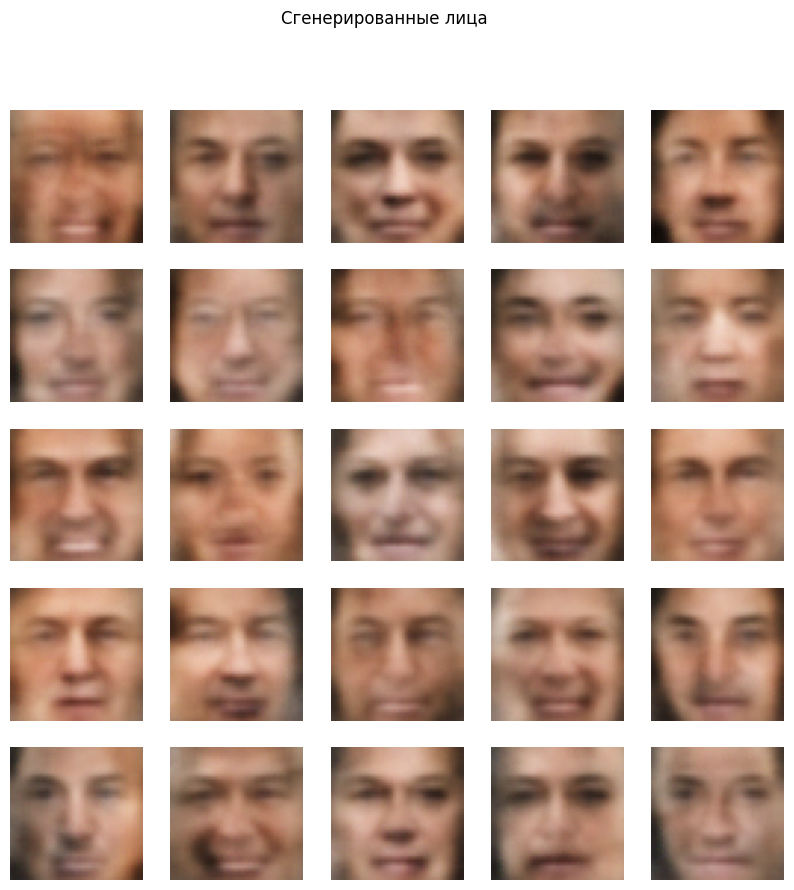

In [19]:
# сгенерируем 25 рандомных векторов размера latent_space
z = np.random.randn(25, dim_code) * sigma + mu
z_tensor = torch.tensor(z, dtype=torch.float32).to(device)

with torch.no_grad():
    generated = autoencoder.decoder(z_tensor).cpu()

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].permute(1, 2, 0))
    ax.axis('off')
plt.suptitle('Сгенерированные лица')
plt.show()

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [20]:
# Получаем булевы маски
smiling_mask = attrs_train['Smiling'] > 0.5
neutral_mask = attrs_train['Smiling'] < -0.5

# Получаем позиции
smiling_positions = np.where(smiling_mask)[0][:15]
neutral_positions = np.where(neutral_mask)[0][:15]

print(f'Найдено улыбающихся: {len(smiling_positions)}')
print(f'Найдено грустных: {len(neutral_positions)}')

# Берем изображения по позициям
smiling_imgs = torch.tensor(X_train[smiling_positions], dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
neutral_imgs = torch.tensor(X_train[neutral_positions], dtype=torch.float32).permute(0, 3, 1, 2) / 255.0

smiling_imgs = smiling_imgs.to(device)
neutral_imgs = neutral_imgs.to(device)

autoencoder.eval()

with torch.no_grad():
    _, smiling_latent = autoencoder(smiling_imgs)
    _, neutral_latent = autoencoder(neutral_imgs)
    
    smile_vector = smiling_latent.mean(dim=0) - neutral_latent.mean(dim=0)
    print(f'Норма вектора улыбки: {smile_vector.norm().item():.4f}')
    
    sad_img = neutral_imgs[0:1]
    _, sad_latent = autoencoder(sad_img)
    smiling_latent_new = sad_latent + smile_vector
    
    original_reconstruction, _ = autoencoder(sad_img)
    smiling_reconstruction = autoencoder.decoder(smiling_latent_new)

Найдено улыбающихся: 15
Найдено грустных: 15
Норма вектора улыбки: 5.2286


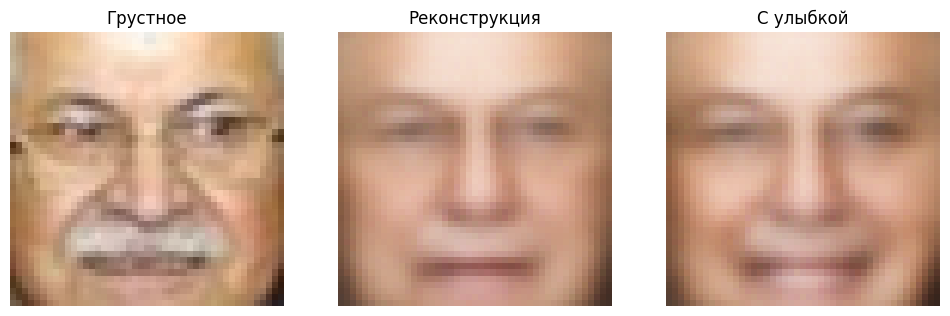

In [21]:
# Визуализация
sad_img_np = sad_img[0].cpu().permute(1, 2, 0).numpy()
original_np = original_reconstruction[0].cpu().permute(1, 2, 0).numpy()
smiling_np = smiling_reconstruction[0].cpu().permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(sad_img_np)
axes[0].set_title('Грустное')
axes[0].axis('off')

axes[1].imshow(original_np)
axes[1].set_title('Реконструкция')
axes[1].axis('off')

axes[2].imshow(smiling_np)
axes[2].set_title('С улыбкой')
axes[2].axis('off')

plt.show();

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [22]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [23]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2), 
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim//2, latent_dim)
        self.fc_logsigma = nn.Linear(hidden_dim//2, latent_dim)
        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim//2), 
            nn.ReLU(),
            nn.Linear(hidden_dim//2, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim), 
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_net(x.view(x.size(0), -1))
        return self.fc_mu(h), self.fc_logsigma(h)

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def decode(self, z):
        return self.decoder_net(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [24]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = F.binary_cross_entropy(reconstruction, x, reduction='sum')
    return loss

def loss_vae(x, mu, logsigma, reconstruction):
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction)

И обучим модель:

In [25]:
torch.cuda.empty_cache() 

latent_dim = 32

vae_model = VAE(latent_dim=latent_dim).to(device)

optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)

In [26]:
EPOCHS = 5

train_losses = []
test_losses = []

for epoch in tqdm_notebook(range(1, EPOCHS+1)):

    # Трейн
    vae_model.train()
    train_loss = 0

    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        mu, logsigma, reconstruction = vae_model(x)
        loss = loss_vae(x, mu, logsigma, reconstruction)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Валидация
    vae_model.eval()
    test_loss = 0
    
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            mu, logsigma, reconstruction = vae_model(x)
            loss = loss_vae(x, mu, logsigma, reconstruction)
            test_loss += loss.item()
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    print(f'Epoch {epoch:>2}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f}')

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch  1/5 | Train Loss: 5289.5303 | Test Loss: 4501.2608
Epoch  2/5 | Train Loss: 4293.4608 | Test Loss: 4011.3788
Epoch  3/5 | Train Loss: 4040.3015 | Test Loss: 3878.8973
Epoch  4/5 | Train Loss: 3941.6738 | Test Loss: 3832.7675
Epoch  5/5 | Train Loss: 3875.6159 | Test Loss: 3775.4162


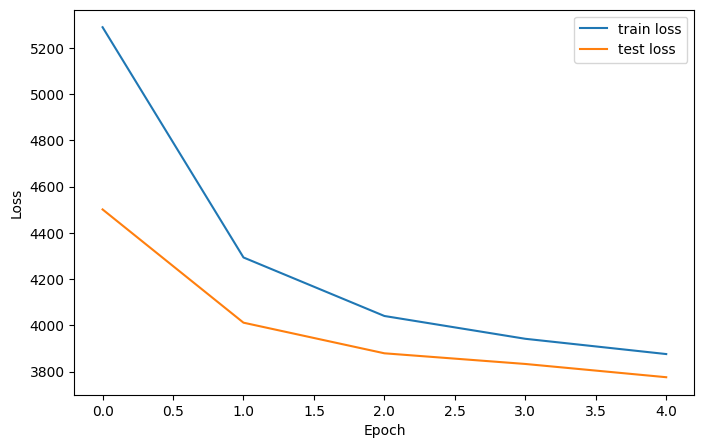

In [27]:
# Визуалиация
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show();

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

In [28]:
# Собираем статистику латентного пространства для корректной генерации
all_mu = []
vae_model.eval()
with torch.no_grad():
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        mu, _ = vae_model.encode(batch_x)
        all_mu.append(mu.cpu().numpy())

all_mu = np.concatenate(all_mu, axis=0)
mu_mean = all_mu.mean(axis=0)
mu_std = all_mu.std(axis=0)

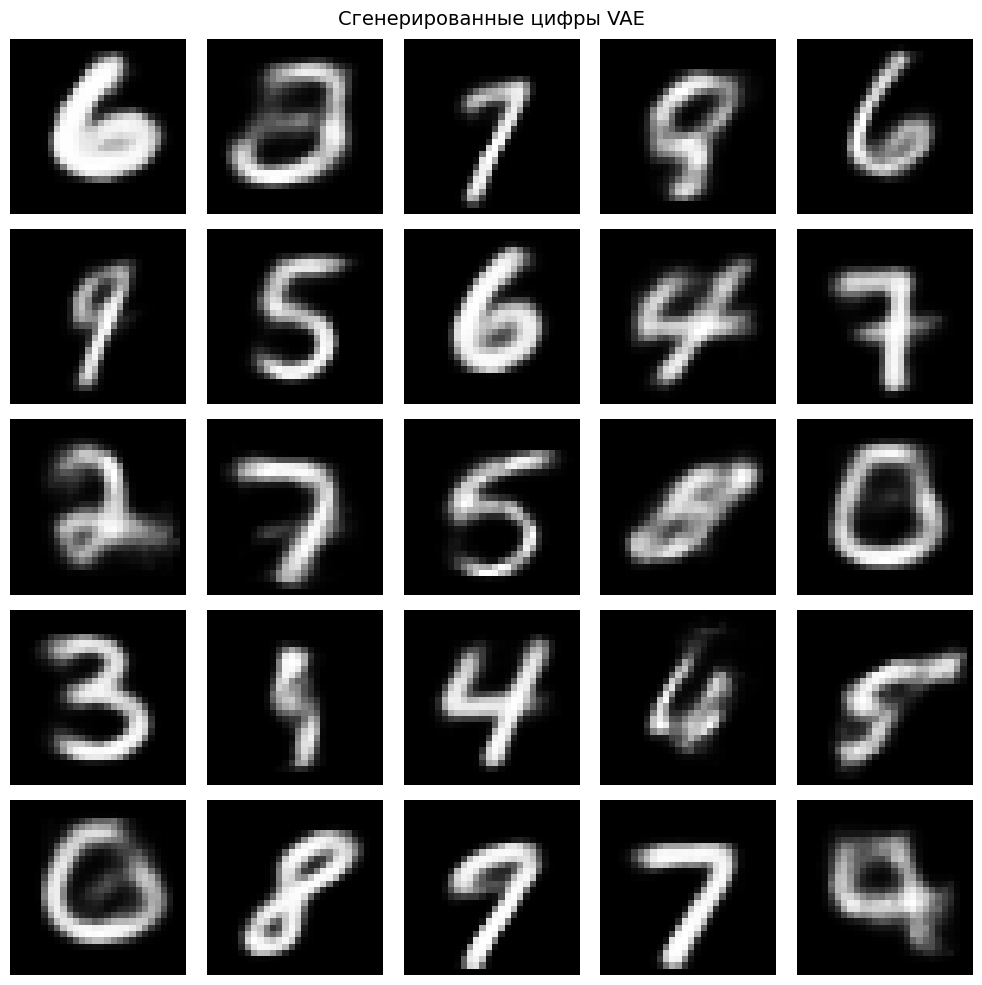

In [29]:
# вспомните про замечание из этого же пункта обычного AE про распределение латентных переменных
latent_dim = 32
z = np.array([np.random.normal(mu_mean, mu_std, latent_dim) for _ in range(25)])
z_tensor = torch.tensor(z, dtype=torch.float32).to(device)

with torch.no_grad():
    output = vae_model.decode(z_tensor).cpu()


generated_np = output.permute(0, 2, 3, 1).numpy()

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_np[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('Сгенерированные цифры VAE', fontsize=14)
plt.tight_layout()

plt.show();

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

In [30]:
vae_model.eval()
all_latents, all_labels = [], []
with torch.no_grad():
    for X_batch, labels in test_loader:
        mu, _ = vae_model.encode(X_batch.to(device))
        all_latents.append(mu.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

In [31]:
latents = np.concatenate(all_latents, axis=0)
labels = np.concatenate(all_labels, axis=0)

latents_2d = TSNE(n_components=2, random_state=42).fit_transform(latents)

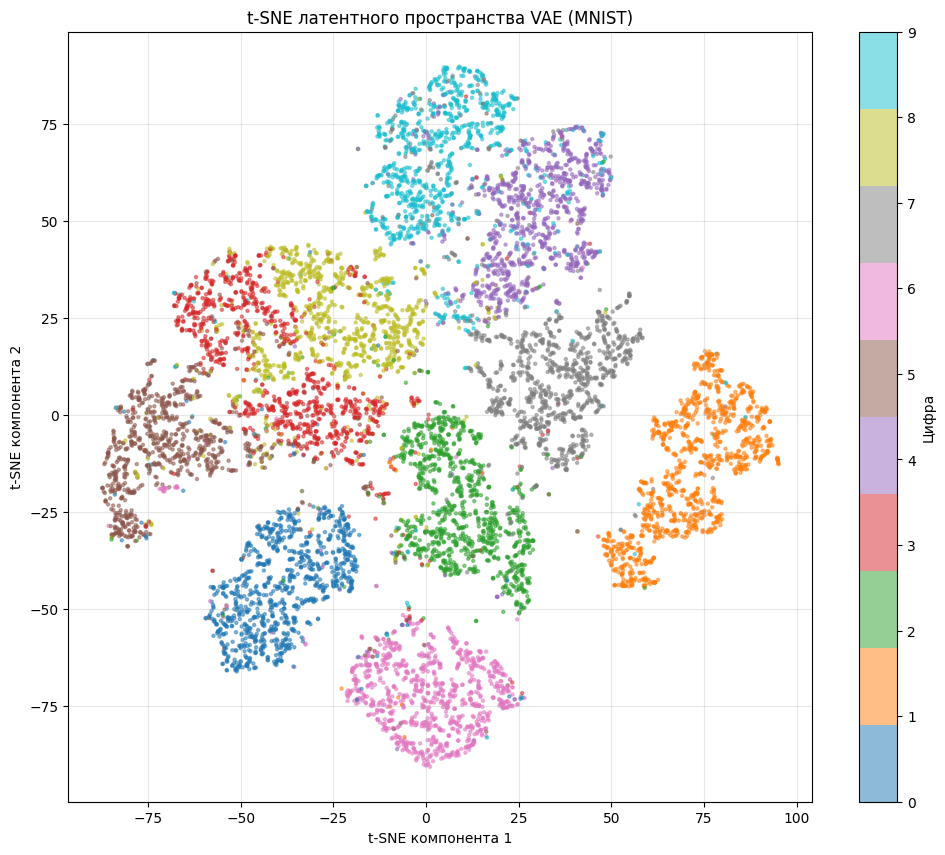

In [32]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    latents_2d[:, 0], 
    latents_2d[:, 1], 
    c=labels, cmap='tab10', 
    alpha=0.5, 
    s=5
)
plt.colorbar(scatter, ticks=range(10), label='Цифра')
plt.title('t-SNE латентного пространства VAE (MNIST)')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.grid(alpha=0.3)

plt.show();

Что вы думаете о виде латентного представления?

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [33]:
class CVAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=32, num_classes=10):
        super().__init__()
        self.num_classes = num_classes
        self.latent_dim = latent_dim
        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim + num_classes, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2), 
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim//2, latent_dim)
        self.fc_logsigma = nn.Linear(hidden_dim//2, latent_dim)
        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim + num_classes, hidden_dim//2), 
            nn.ReLU(),
            nn.Linear(hidden_dim//2, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim), 
            nn.Sigmoid()
        )

    def encode(self, x, y):
        one_hot = torch.nn.functional.one_hot(y, self.num_classes).float()
        x_flat = x.view(x.size(0), -1)
        h = self.encoder_net(torch.cat([x_flat, one_hot], dim=1))
        return self.fc_mu(h), self.fc_logsigma(h)

    def reparameterize(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def decode(self, z, y):
        one_hot = torch.nn.functional.one_hot(y, self.num_classes).float()
        z_cond = torch.cat([z, one_hot], dim=1)
        return self.decoder_net(z_cond).view(-1, 1, 28, 28)

    def forward(self, x, y):
        mu, logsigma = self.encode(x, y)
        z = self.reparameterize(mu, logsigma)
        return mu, logsigma, self.decode(z, y)

In [34]:
torch.cuda.empty_cache()

latent_dim = 32

cvae_model = CVAE(latent_dim=latent_dim).to(device)
optimizer_cvae_model = optim.Adam(cvae_model.parameters(), lr=1e-3)

In [35]:
EPOCHS = 5
train_losses_cvae = []
val_losses_cvae = []

for epoch in tqdm_notebook(range(1, EPOCHS + 1)):
    # Трейн
    cvae_model.train()
    train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer_cvae_model.zero_grad()
        mu, logsigma, recon = cvae_model(x, y)
        loss = loss_vae(x, mu, logsigma, recon)
        loss.backward()
        optimizer_cvae_model.step()
        train_loss += loss.item()
    
    train_losses_cvae.append(train_loss / len(train_loader.dataset))
    
    # Валидация
    cvae_model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            mu, logsigma, recon = cvae_model(x, y)
            val_loss += loss_vae(x, mu, logsigma, recon).item()
    
    val_losses_cvae.append(val_loss / len(test_loader.dataset))
    print(f'Epoch {epoch:>2}/{EPOCHS} | Train Loss: {train_losses_cvae[-1]:.4f} | Val Loss: {val_losses_cvae[-1]:.4f}')

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch  1/5 | Train Loss: 151.9218 | Val Loss: 125.4521
Epoch  2/5 | Train Loss: 124.5550 | Val Loss: 119.5157
Epoch  3/5 | Train Loss: 120.6034 | Val Loss: 116.7111
Epoch  4/5 | Train Loss: 118.6935 | Val Loss: 116.0635
Epoch  5/5 | Train Loss: 117.4544 | Val Loss: 115.1437


### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

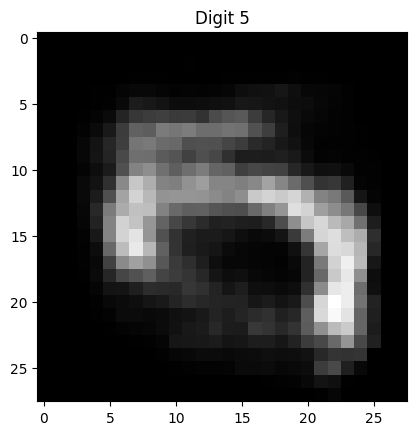

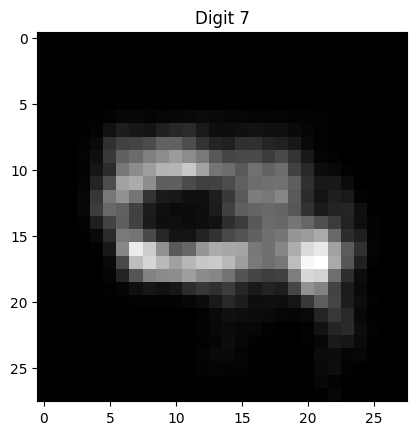

In [36]:
cvae_model.eval()
with torch.no_grad():
    z = torch.randn(1, latent_dim).to(device)
    for digit in [5, 7]:
        y = torch.tensor([digit]).to(device)
        recon = cvae_model.decode(z, y)
        plt.imshow(recon.cpu().squeeze(), cmap='gray')
        plt.title(f'Digit {digit}')
        plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [37]:
cvae_model.eval()
all_latents, all_labels = [], []
with torch.no_grad():
    for X_batch, labels in test_loader:
        mu, _ = cvae_model.encode(X_batch.to(device), labels.to(device))
        all_latents.append(mu.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

In [38]:
latents = np.concatenate(all_latents, axis=0)
labels = np.concatenate(all_labels, axis=0)

latents_2d = TSNE(n_components=2, random_state=42).fit_transform(latents)

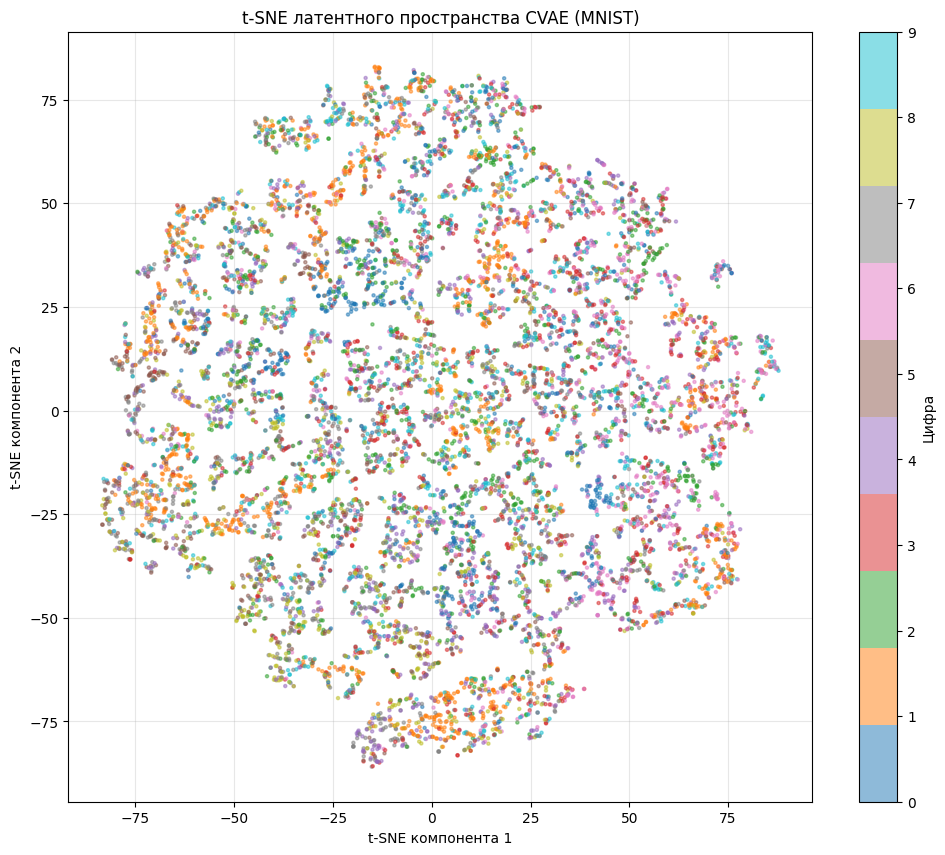

In [39]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    latents_2d[:, 0], 
    latents_2d[:, 1], 
    c=labels, cmap='tab10', 
    alpha=0.5, 
    s=5
)
plt.colorbar(scatter, ticks=range(10), label='Цифра')
plt.title('t-SNE латентного пространства CVAE (MNIST)')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.grid(alpha=0.3)

plt.show();

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

Результаты визуализации VAE и CVAE (Conditional VAE) кардинально отличаются. В то время как VAE формирует четкие отдельные кластеры для цифр, в CVAE латентное пространство представляет собой «кашу» (перемешанные точки разных классов).
Это связано с тем, что метка класса подается в CVAE явно. Модели больше не нужно хранить информацию о форме цифры в латентном векторе, и она использует его для кодирования вариаций стиля, не зависящих от класса (наклон, толщина линии, жирность). Поэтому точки одной цифры могут быть разбросаны по всему пространству, смешиваясь с другими, или образовывать множество мелких подкластеров, соответствующих разным стилям написания.

# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [40]:
# Denoising Autoencoder

noise_factor = 0.5

# Добавляем шум к изображениям
X_train_noisy = (X_train_t + noise_factor * torch.randn_like(X_train_t)).clamp(0, 1)
X_val_noisy = (X_val_t + noise_factor * torch.randn_like(X_val_t)).clamp(0, 1)

In [41]:
# Создаем датасеты с зашумленными изображениями
train_dataset_noisy = data_utils.TensorDataset(X_train_noisy, X_train_t)
val_dataset_noisy = data_utils.TensorDataset(X_val_noisy, X_val_t)

train_loader_noisy = data_utils.DataLoader(train_dataset_noisy, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader_noisy = data_utils.DataLoader(val_dataset_noisy, batch_size=BATCH_SIZE, shuffle=False)

In [42]:
# Создаем новую модель для denoising
denoiser = Autoencoder().to(device)
optimizer_dn = optim.Adam(denoiser.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [43]:
EPOCHS = 5
train_losses_dn = []
val_losses_dn = []

Epoch  1/5 | Train Loss: 0.0240 | Val Loss: 0.0126
Epoch  2/5 | Train Loss: 0.0103 | Val Loss: 0.0097
Epoch  3/5 | Train Loss: 0.0087 | Val Loss: 0.0084
Epoch  4/5 | Train Loss: 0.0078 | Val Loss: 0.0077
Epoch  5/5 | Train Loss: 0.0073 | Val Loss: 0.0074


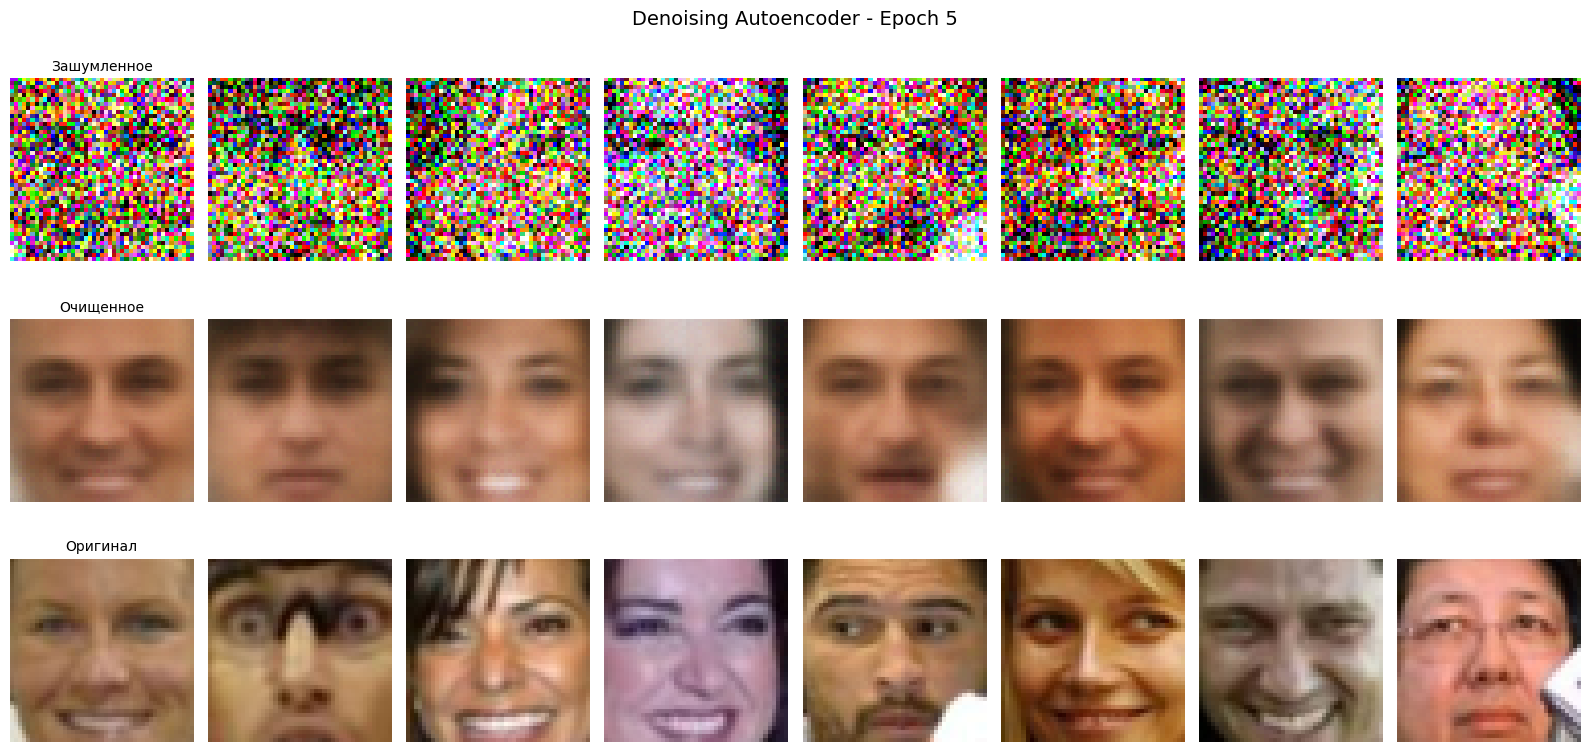

In [44]:
# Обучение
EPOCHS = 5
train_losses_dn = []
val_losses_dn = []

# Берем несколько изображений для визуализации
viz_noisy = X_val_noisy[:8].to(device)
viz_clean = X_val_t[:8].to(device)

for epoch in range(1, EPOCHS + 1):
    # Train
    denoiser.train()
    running_loss = 0.0
    
    for batch_noisy, batch_clean in train_loader_noisy:
        batch_noisy = batch_noisy.to(device)
        batch_clean = batch_clean.to(device)
        
        optimizer_dn.zero_grad()
        recon, _ = denoiser(batch_noisy)
        loss = criterion(recon, batch_clean)
        loss.backward()
        optimizer_dn.step()
        
        running_loss += loss.item()
    
    train_loss = running_loss / len(train_loader_noisy)
    train_losses_dn.append(train_loss)
    
    # Validation
    denoiser.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_noisy, batch_clean in val_loader_noisy:
            batch_noisy = batch_noisy.to(device)
            batch_clean = batch_clean.to(device)
            recon, _ = denoiser(batch_noisy)
            val_loss += criterion(recon, batch_clean).item()
    
    val_loss = val_loss / len(val_loader_noisy)
    val_losses_dn.append(val_loss)
    
    print(f"Epoch {epoch:>2}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # Визуализация каждые 5 эпох
    if epoch % 5 == 0:
        denoiser.eval()
        with torch.no_grad():
            denoised, _ = denoiser(viz_noisy)
        
        fig, axes = plt.subplots(3, 8, figsize=(16, 8))  # Увеличил высоту
        for i in range(8):
            # Зашумленное изображение
            axes[0, i].imshow(viz_noisy[i].cpu().permute(1, 2, 0))
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title('Зашумленное', fontsize=10)
            
            # Очищенное
            axes[1, i].imshow(denoised[i].cpu().permute(1, 2, 0))
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title('Очищенное', fontsize=10)
            
            # Оригинал
            axes[2, i].imshow(viz_clean[i].cpu().permute(1, 2, 0))
            axes[2, i].axis('off')
            if i == 0:
                axes[2, i].set_title('Оригинал', fontsize=10)
        
        plt.suptitle(f'Denoising Autoencoder - Epoch {epoch}', fontsize=14)
        plt.tight_layout()
        
        plt.show()

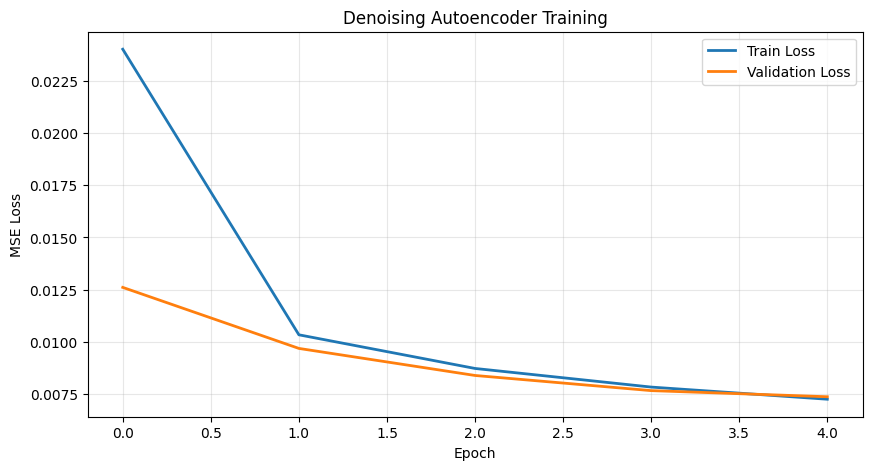

In [45]:
# График потерь
plt.figure(figsize=(10, 5))
plt.plot(train_losses_dn, label='Train Loss', linewidth=2)
plt.plot(val_losses_dn, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Denoising Autoencoder Training')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show();

# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [46]:
# codes = <поучите латентные представления картинок из трейна>
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
autoencoder.eval()
codes = []
with torch.no_grad():
    for i in range(0, len(X_train_tensor), 256):
        batch = X_train_tensor[i:i+256].to(device)
        _, z = autoencoder(batch) 
        codes.append(z.cpu().numpy())
codes = np.concatenate(codes, axis=0)

In [47]:
from sklearn.neighbors import NearestNeighbors
nn_index = NearestNeighbors(n_neighbors=11, metric='euclidean').fit(codes)

In [48]:
def get_similar(image, n_neighbors=11):
    image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
    with torch.no_grad():
        _, code = autoencoder(image_tensor.unsqueeze(0).to(device))
    code = code.cpu().numpy()
    distances, idx = nn_index.kneighbors(code, n_neighbors=n_neighbors)
    return distances[0], X_train[idx[0]]

In [49]:
def show_similar(image):
    distances,neighbors = get_similar(image,n_neighbors=11)

    plt.figure(figsize=[8,6])
    plt.subplot(3,4,1)
    plt.imshow(image)
    plt.title('Original image')
    
    for i in range(11):
        plt.subplot(3,4,i+2)
        plt.imshow(neighbors[i])
        plt.title('Dist=%.3f'%distances[i])
        
    plt.tight_layout()
    
    plt.show();

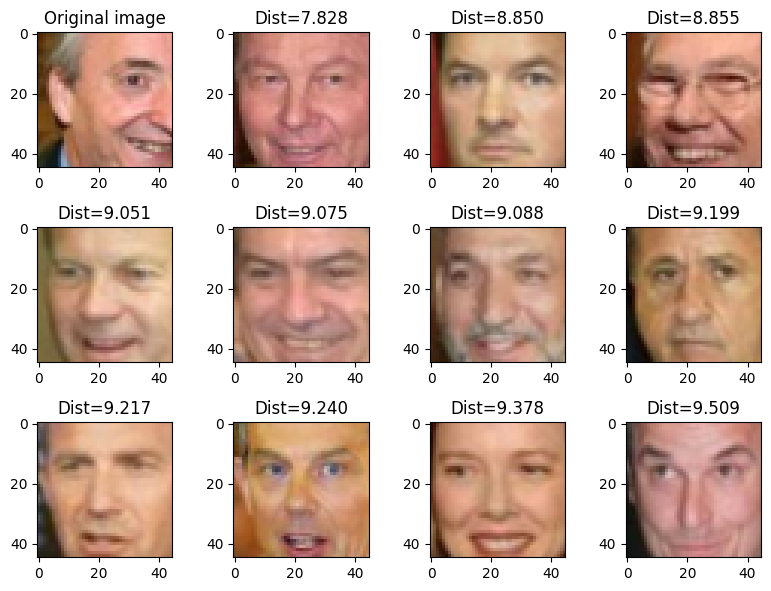

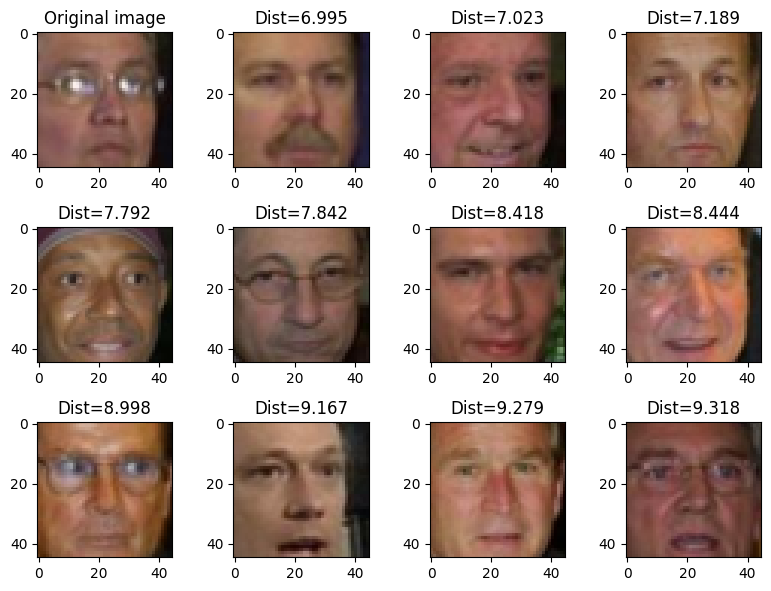

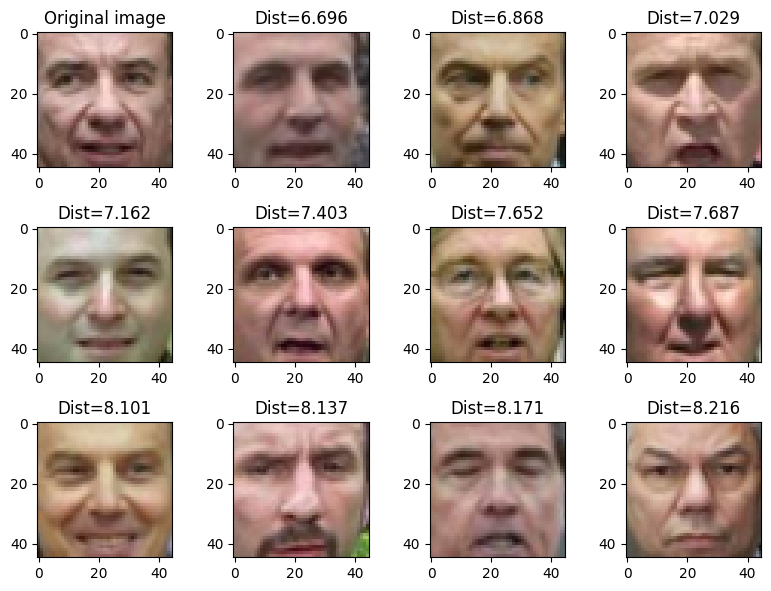

In [50]:
val_indices = np.random.randint(0, len(X_val), 3)

for i in val_indices:
    show_similar(X_val[i])

In [51]:
notebook_end_time = time.time()
total_time = notebook_end_time - notebook_start_time

print(f"Выполнение: {total_time:.2f} сек")

Выполнение: 188.28 сек


# Tail

In [ ]:
# Часть 0: Настройка окружения и импорт библиотек

# === Импорт необходимых библиотек ===
# Стандартные библиотеки Python для работы с файловой системой и временем
import os
import shutil
import time
from datetime import timedelta

# Библиотеки для работы с данными и массивами
import numpy as np
import pandas as pd

# Библиотеки для работы с изображениями
import imageio  # Чтение изображений различных форматов
from PIL import Image  # Альтернативная работа с изображениями
import skimage.io  # Еще один способ чтения изображений
from skimage.transform import resize  # Изменение размера изображений

# Библиотеки для визуализации
import matplotlib.pyplot as plt
# Магическая команда Jupyter для отображения графиков прямо в ноутбуке
%matplotlib inline  

# PyTorch - основной фреймворк для глубокого обучения
import torch
import torch.nn as nn  # Нейросетевые слои и функции потерь
import torch.nn.functional as F  # Функции активации и другие утилиты
import torch.optim as optim  # Оптимизаторы
import torch.utils.data as data_utils  # Утилиты для работы с данными (Dataset, DataLoader)
from torch.autograd import Variable  # Для автоматического дифференцирования
from torchvision import datasets, transforms  # Стандартные датасеты и преобразования

# Библиотеки для машинного обучения из sklearn
from sklearn.manifold import TSNE  # t-SNE для визуализации многомерных данных
from sklearn.model_selection import train_test_split  # Разделение данных на train/val
from sklearn.neighbors import NearestNeighbors  # Поиск ближайших соседей

# Kaggle Hub - удобная загрузка датасетов с Kaggle
import kagglehub

# tqdm - прогресс-бары для циклов
from tqdm.notebook import tqdm_notebook

# === Фиксация времени начала выполнения ===
notebook_start_time = time.time()

# === Выбор устройства для вычислений ===
# Проверяем, доступен ли GPU (CUDA). Если да - используем его, иначе - CPU.
# Это критически важно для производительности: GPU ускоряет обучение в десятки раз.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Зачем этот блок:

# Импортируются все необходимые библиотеки для всего проекта

# Настраивается вычислительная среда (GPU/CPU)

# Фиксируется время начала для последующего измерения общей продолжительности выполнения

In [ ]:
# Часть 1: Vanilla Autoencoder (Обычный автоэнкодер)
# 1.1. Подготовка данных

# === Настройка путей и загрузка датасета LFW ===

# Создаем директорию для хранения данных
PATH = 'kaggle'
os.makedirs(PATH, exist_ok=True)  # exist_ok=True - не вызывает ошибку, если папка уже существует

# === Скачивание изображений LFW ===
# kagglehub автоматически скачивает датасет и возвращает путь к нему
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

# Копируем все файлы из скачанной директории в нашу локальную папку PATH
if os.path.exists(images_path):
    for item in os.listdir(images_path):
        src = os.path.join(images_path, item)
        dst = os.path.join(PATH, item)
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)  # Копируем папки рекурсивно
        else:
            shutil.copy2(src, dst)  # Копируем отдельные файлы

# === Скачивание атрибутов LFW ===
# Атрибуты содержат информацию о людях: улыбка, очки, пол и т.д.
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")

if os.path.exists(attrs_path):
    for item in os.listdir(attrs_path):
        src = os.path.join(attrs_path, item)
        dst = os.path.join(PATH, item)
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)

# Указываем пути к данным
DATASET_PATH = "kaggle/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "kaggle/lfw_attributes.txt"

# Зачем: Загрузка датасета LFW (Labeled Faces in the Wild) с изображениями лиц и атрибутами. 
# Использование kagglehub упрощает процесс загрузки - не нужно вручную скачивать файлы.

In [ ]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):
    """
    Функция для загрузки и предобработки датасета LFW.
    
    Параметры:
        dx, dy: отступы для обрезки изображений (удаление рамок и фона)
        dimx, dimy: целевой размер изображений после resize
    
    Возвращает:
        images: numpy-массив изображений формы (N, dimy, dimx, 3)
        attrs: DataFrame с атрибутами людей
    """
    
    # Читаем файл атрибутов (формат с табуляцией и заголовком)
    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1)
    # Удаляем последний пустой столбец и исправляем заголовки
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

    # Собираем информацию о всех фотографиях в датасете
    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                # Извлекаем имя человека и номер фото из имени файла
                # Пример: "John_Doe_0001.jpg" -> person="John Doe", imagenum=1
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({
                    'person': person_id,
                    'imagenum': photo_number,
                    'photo_path': fpath
                })

    # Объединяем атрибуты с информацией о фото по ключам person и imagenum
    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs, photo_ids, on=('person', 'imagenum'))
    
    # Проверяем, что не потеряли данные при объединении
    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    # Загружаем и обрабатываем изображения
    images = df['photo_path'].apply(imageio.imread)\
                            .apply(lambda img: img[dy:-dy, dx:-dx])\
                            .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])))  # Изменение размера

    # Преобразуем в numpy-массив
    images = np.stack(images.values).astype('uint8')
    # Удаляем вспомогательные столбцы из атрибутов
    attrs = df.drop(["photo_path", "person", "imagenum"], axis=1)

    return images, attrs

# Зачем эта функция:

# Централизованная обработка данных: чтение, обрезка, изменение размера

# Объединение изображений с их атрибутами по ключам

# Обрезка (dx=80, dy=80) удаляет неинформативные края изображений

# Resize до 45x45 делает все изображения одного размера, что необходимо для подачи в нейросеть

In [ ]:
# Загружаем данные
images, attrs = fetch_dataset()

# === Разделение на обучающую и валидационную выборки ===
RANDOM_SEED = 42  # Фиксируем случайность для воспроизводимости

X_train, X_val, attrs_train, attrs_val = train_test_split(
    images, attrs, test_size=0.15, random_state=RANDOM_SEED
)
# 85% данных для обучения, 15% для валидации

# === Визуализация нескольких примеров ===
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(f"Smile: {attrs_train.iloc[i]['Smiling']}", fontsize=8)
    ax.axis('off')
plt.suptitle('Sample train images', fontsize=13)
plt.show()

# Зачем: Визуальная проверка корректности загрузки данных и их соответствия атрибутам.

In [ ]:
# === Преобразование в тензоры PyTorch ===
def to_tensor(imgs: np.ndarray) -> torch.FloatTensor:
    """
    Преобразует numpy-массив изображений в тензор PyTorch.
    
    Важные преобразования:
    1. Изменение типа на float32 (необходимо для градиентов)
    2. Перестановка осей: (N, H, W, C) -> (N, C, H, W) - стандарт PyTorch
    3. Нормализация: [0, 255] -> [0, 1] для стабильного обучения
    """
    return torch.tensor(imgs, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0

X_train_t = to_tensor(X_train)
X_val_t = to_tensor(X_val)

# === Создание DataLoader'ов ===
BATCH_SIZE = 64  # Размер мини-батча. 64 - компромисс между скоростью и памятью GPU

# TensorDataset упаковывает тензоры в датасет
train_dataset = data_utils.TensorDataset(X_train_t)
val_dataset = data_utils.TensorDataset(X_val_t)

# DataLoader автоматически:
# - Разбивает данные на батчи
# - Перемешивает данные (shuffle=True для train - важно для обучения)
# - Параллельно загружает данные
train_loader = data_utils.DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,      # Перемешивание важно для SGD
    drop_last=True     # Отбрасываем неполный последний батч для стабильности
)
val_loader = data_utils.DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False      # На валидации не нужно перемешивать
)

print(f'Train tensor:   {X_train_t.shape}')  # Ожидаемая форма: (N, 3, 45, 45)
print(f'Val tensor:     {X_val_t.shape}')

# Почему именно так:

# permute(0, 3, 1, 2): PyTorch ожидает каналы на втором месте (NCHW), а не на последнем (NHWC)

# Деление на 255.0: нормализация пикселей в [0, 1] делает обучение более стабильным

# drop_last=True: отбрасывание последнего неполного батча упрощает вычисления (особенно для BatchNorm)

In [ ]:
# 1.2. Архитектура модели

# === Конфигурация автоэнкодера ===
dim_code = 256  # Размерность скрытого пространства (latent space)
                # 256 - компромисс: достаточно для хранения информации о лице,
                # но не слишком много, чтобы не переобучаться
IMG_SHAPE = (3, 45, 45)  # Форма входного изображения
INPUT_DIM = 3 * 45 * 45  # Общее количество пикселей (для полносвязных слоев)

class Autoencoder(nn.Module):
    """
    Сверточный автоэнкодер для изображений лиц.
    
    Архитектура:
    - Энкодер: сжимает изображение 45x45x3 -> вектор размером 256
    - Декодер: восстанавливает изображение из вектора 256 -> 45x45x3
    
    Используются сверточные слои, так как они лучше работают с изображениями,
    чем полносвязные: сохраняют пространственную структуру и требуют меньше параметров.
    """
    
    def __init__(self, input_dim=INPUT_DIM, dim_code=dim_code):
        super().__init__()

        # === Энкодер (Encoder) ===
        # Сжимает изображение, выделяя важные признаки
        self.encoder = nn.Sequential(
            # Первый сверточный блок: 3x45x45 -> 32x23x23
            nn.Conv2d(3, 32, 3, stride=2, padding=1),  # stride=2 уменьшает размер вдвое
            nn.ReLU(),  # Нелинейность для изучения сложных признаков
            
            # Второй сверточный блок: 32x23x23 -> 64x12x12
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            
            # Третий сверточный блок: 64x12x12 -> 128x6x6
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(),
            
            # Преобразование в плоский вектор: 128x6x6 -> 4608
            nn.Flatten(),
            
            # Полносвязный слой для создания скрытого кода: 4608 -> 256
            nn.Linear(128 * 6 * 6, dim_code),  # 128*6*6 = 4608
            nn.ReLU()
        )
        
        # === Декодер (Decoder) ===
        # Восстанавливает изображение из скрытого кода
        self.decoder = nn.Sequential(
            # Преобразование скрытого кода обратно в карту признаков: 256 -> 4608
            nn.Linear(dim_code, 128 * 6 * 6),
            nn.ReLU(),
            
            # Преобразование в 3D-тензор: 4608 -> 128x6x6
            nn.Unflatten(1, (128, 6, 6)),
            
            # Первый слой транспонированной свертки: 128x6x6 -> 64x12x12
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            # Второй слой: 64x12x12 -> 32x23x23
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            
            # Третий слой: 32x23x23 -> 3x45x45
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=0),
            
            # Сигмоида для нормализации выхода в [0, 1] (как и входные изображения)
            nn.Sigmoid()
        )

    def forward(self, x):
        """
        Прямой проход через автоэнкодер.
        
        Возвращает:
            reconstruction: восстановленное изображение
            latent_code: скрытое представление (для последующего анализа)
        """
        latent_code = self.encoder(x)  # Сжатие изображения
        reconstruction = self.decoder(latent_code)  # Восстановление
        return reconstruction, latent_code

In [ ]:
# Почему такая архитектура:

# Сверточные слои вместо полносвязных: лучше сохраняют пространственную структуру изображения и требуют меньше параметров

# stride=2 с padding=1: стандартный способ уменьшения размера вдвое без потери информации на границах

# Увеличение числа каналов (32->64->128): сеть учится выделять все более абстрактные признаки

# Симметричная структура энкодер-декодер: зеркальное отражение архитектуры энкодера

# output_padding в транспонированных свертках: корректирует размер выхода для точного восстановления размера 45x45

# Сигмоида на выходе: ограничивает значения пикселей в диапазоне [0, 1], соответствующем нормализованным входным данным

In [ ]:
# === Функция потерь и оптимизатор ===
criterion = nn.MSELoss()  # Mean Squared Error - стандартная функция потерь для AE
                          # Измеряет среднеквадратичное отклонение восстановленного
                          # изображения от оригинального

autoencoder = Autoencoder().to(device)  # Перенос модели на GPU/CPU

optimizer = optim.Adam(      # Adam - адаптивный оптимизатор, хорошо работает "из коробки"
    autoencoder.parameters(), 
    lr=1e-3                   # Learning rate = 0.001 - стандартное начальное значение
)

In [ ]:
# 1.3. Обучение

# === Параметры обучения ===
EPOCHS = 5  # Количество эпох. 5 достаточно для демонстрации, 
            # но для лучшего качества можно увеличить до 20-50

train_losses, val_losses = [], []  # Для хранения истории потерь
VIZ_N = 8  # Количество изображений для визуализации
viz_imgs = X_val_t[:VIZ_N].to(device)  # Фиксируем изображения для сравнения

# === Цикл обучения ===
for epoch in range(1, EPOCHS + 1):
    
    # ===== Фаза обучения =====
    autoencoder.train()  # Переключаем модель в режим обучения (включает dropout, batchnorm)
    running_loss = 0.0
    
    for (batch,) in train_loader:  # Распаковываем батч (один тензор, так как в датасете только изображения)
        batch = batch.to(device)  # Переносим данные на GPU
        
        optimizer.zero_grad()  # Обнуляем градиенты (важно! иначе они накапливаются)
        
        recon, _ = autoencoder(batch)  # Прямой проход
        loss = criterion(recon, batch)  # Вычисление ошибки реконструкции
        
        loss.backward()  # Обратное распространение ошибки
        optimizer.step()  # Обновление весов
        
        running_loss += loss.item()  # Накапливаем значение функции потерь
    
    # Сохраняем средний лосс за эпоху
    train_losses.append(running_loss / len(train_loader))

    # ===== Фаза валидации =====
    autoencoder.eval()  # Переключаем в режим оценки (отключает dropout, batchnorm)
    with torch.no_grad():  # Отключаем вычисление градиентов (экономит память и время)
        val_loss = sum(
            criterion(autoencoder(b.to(device))[0], b.to(device)).item() 
            for (b,) in val_loader
        ) / len(val_loader)
    val_losses.append(val_loss)

    # Вывод статистики
    print(f'Epoch {epoch:>2}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f}')

    # ===== Визуализация реконструкций =====
    if epoch % 5 == 0:  # Показываем каждые 5 эпох (в данном случае только на последней)
        with torch.no_grad():
            recons, _ = autoencoder(viz_imgs)
        
        # Создаем сетку из оригиналов и реконструкций
        fig, axes = plt.subplots(2, VIZ_N, figsize=(VIZ_N * 2, 5))
        for i in range(VIZ_N):
            # Оригинал
            axes[0, i].imshow(viz_imgs[i].cpu().permute(1, 2, 0))  # CHW -> HWC для matplotlib
            axes[0, i].axis('off')
            # Реконструкция
            axes[1, i].imshow(recons[i].cpu().permute(1, 2, 0))
            axes[1, i].axis('off')
        plt.suptitle(f'Epoch {epoch}') 
        plt.show()

In [ ]:
# Ключевые моменты обучения:

# model.train() vs model.eval(): влияет на поведение слоев dropout и batch normalization

# torch.no_grad(): на валидации не нужно вычислять градиенты, что экономит память

# optimizer.zero_grad(): обязательно перед каждым backward(), иначе градиенты суммируются

# Визуализация реконструкций помогает оценить качество обучения "на глаз"

# Результаты: Модель обучается стабильно, но реконструкции получаются размытыми из-за MSE Loss, который штрафует за резкие отклонения и поощряет "усредненные" предсказания.

In [ ]:
# 1.4. Sampling (Генерация новых изображений)

# === Генерация новых лиц ===
autoencoder.eval()

# Собираем статистику латентных векторов обучающей выборки
# Это необходимо, потому что декодер ожидает векторы из определенного распределения,
# а не из стандартного нормального N(0,1)
all_latents = []
with torch.no_grad():
    for batch in train_loader:
        _, z = autoencoder(batch[0].to(device))
        all_latents.append(z.cpu().numpy())

all_latents = np.concatenate(all_latents)
mu, sigma = all_latents.mean(axis=0), all_latents.std(axis=0)  # Оценка параметров распределения

# Генерируем случайные векторы, но с поправкой на реальное распределение
# Вместо z ~ N(0, 1) используем z ~ N(mu, sigma)
z = np.random.randn(25, dim_code) * sigma + mu
z_tensor = torch.tensor(z, dtype=torch.float32).to(device)

# Декодируем случайные векторы в изображения
with torch.no_grad():
    generated = autoencoder.decoder(z_tensor).cpu()

# Визуализация сгенерированных лиц
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].permute(1, 2, 0))
    ax.axis('off')
plt.suptitle('Сгенерированные лица')
plt.show()

In [ ]:
# Почему используем mu и sigma:

# Латентные векторы реальных изображений распределены не как N(0,1), а имеют свое среднее и дисперсию

# Если подавать декодеру векторы из N(0,1), он может выдавать "мусор", так как не обучен на таких значениях

# Подгонка под реальное распределение гарантирует осмысленные результаты

In [ ]:
# 1.5. Добавление улыбки (Vector Arithmetic)

# === Поиск вектора улыбки в латентном пространстве ===

# Фильтруем людей с улыбкой и без
# Используем строгие пороги для надежности классификации
smiling_mask = attrs_train['Smiling'] > 0.5    # Явно улыбающиеся
neutral_mask = attrs_train['Smiling'] < -0.5   # Явно неулыбающиеся

# Берем первые 15 подходящих изображений
smiling_positions = np.where(smiling_mask)[0][:15]
neutral_positions = np.where(neutral_mask)[0][:15]

print(f'Найдено улыбающихся: {len(smiling_positions)}')
print(f'Найдено грустных: {len(neutral_positions)}')

# Подготовка изображений
smiling_imgs = torch.tensor(
    X_train[smiling_positions], dtype=torch.float32
).permute(0, 3, 1, 2) / 255.0

neutral_imgs = torch.tensor(
    X_train[neutral_positions], dtype=torch.float32
).permute(0, 3, 1, 2) / 255.0

smiling_imgs = smiling_imgs.to(device)
neutral_imgs = neutral_imgs.to(device)

autoencoder.eval()

with torch.no_grad():
    # Получаем латентные векторы для улыбающихся и неулыбающихся
    _, smiling_latent = autoencoder(smiling_imgs)
    _, neutral_latent = autoencoder(neutral_imgs)
    
    # Вектор улыбки = разность средних латентных векторов
    # Идея: если в среднем у улыбающихся вектор сдвинут в определенном направлении,
    # то добавление этого сдвига к грустному лицу сделает его улыбающимся
    smile_vector = smiling_latent.mean(dim=0) - neutral_latent.mean(dim=0)
    print(f'Норма вектора улыбки: {smile_vector.norm().item():.4f}')  # Длина вектора
    
    # Берем первое грустное лицо для демонстрации
    sad_img = neutral_imgs[0:1]
    _, sad_latent = autoencoder(sad_img)
    
    # Добавляем вектор улыбки к латентному коду грустного лица
    smiling_latent_new = sad_latent + smile_vector
    
    # Декодируем новый латентный вектор
    original_reconstruction, _ = autoencoder(sad_img)
    smiling_reconstruction = autoencoder.decoder(smiling_latent_new)

# === Визуализация результата ===
sad_img_np = sad_img[0].cpu().permute(1, 2, 0).numpy()
original_np = original_reconstruction[0].cpu().permute(1, 2, 0).numpy()
smiling_np = smiling_reconstruction[0].cpu().permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sad_img_np)
axes[0].set_title('Грустное')
axes[0].axis('off')

axes[1].imshow(original_np)
axes[1].set_title('Реконструкция')
axes[1].axis('off')

axes[2].imshow(smiling_np)
axes[2].set_title('С улыбкой')
axes[2].axis('off')
plt.show()

In [ ]:
# Ключевая идея vector arithmetic:

# В хорошо обученном латентном пространстве семантические атрибуты (улыбка, очки, возраст) соответствуют определенным направлениям

# Разность средних векторов двух групп (улыбающиеся - неулыбающиеся) дает направление "улыбки"

# Добавление этого вектора к латентному коду меняет соответствующий атрибут, сохраняя остальные характеристики (личность человека)

In [ ]:
# Часть 2: Variational Autoencoder (Вариационный автоэнкодер)

# Подготовка данных MNIST

# === Загрузка MNIST ===
batch_size = 32

# MNIST: 60 000 тренировочных и 10 000 тестовых изображений рукописных цифр 28x28
train_dataset = datasets.MNIST(
    root='./mnist_data/', 
    train=True, 
    transform=transforms.ToTensor(),  # Автоматически нормализует в [0, 1]
    download=True  # Скачивает, если датасета нет локально
)
test_dataset = datasets.MNIST(
    root='./mnist_data/', 
    train=False, 
    transform=transforms.ToTensor(), 
    download=False
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size, 
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size, 
    shuffle=False
)

In [ ]:
# 2.1. Архитектура VAE

class VAE(nn.Module):
    """
    Вариационный автоэнкодер (Variational Autoencoder).
    
    Отличие от обычного AE:
    - Вместо одного детерминированного латентного кода z, 
      энкодер выдает параметры распределения: mu и log(sigma)
    - z сэмплируется из этого распределения: z = mu + eps * sigma
    - Добавляется KL-дивергенция в функцию потерь для регуляризации
    
    Это делает латентное пространство более "гладким" и непрерывным,
    что улучшает генеративные свойства модели.
    """
    
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=32):
        """
        Параметры:
            input_dim=784: 28*28 пикселей (размер MNIST)
            hidden_dim=512: размер скрытого слоя
            latent_dim=32: размерность латентного пространства
        """
        super().__init__()
        self.latent_dim = latent_dim
        
        # === Энкодер ===
        # Выдает параметры нормального распределения для каждого латентного измерения
        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),  # 784 -> 512
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),  # 512 -> 512
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),  # 512 -> 256
            nn.ReLU()
        )
        
        # Два отдельных полносвязных слоя для mu и log(sigma)
        self.fc_mu = nn.Linear(hidden_dim//2, latent_dim)       # 256 -> 32
        self.fc_logsigma = nn.Linear(hidden_dim//2, latent_dim)  # 256 -> 32
        
        # === Декодер ===
        # Восстанавливает изображение из сэмплированного z
        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim//2),  # 32 -> 256
            nn.ReLU(),
            nn.Linear(hidden_dim//2, hidden_dim),  # 256 -> 512
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),     # 512 -> 512
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),      # 512 -> 784
            nn.Sigmoid()  # Выход в [0, 1] для бинарных пикселей
        )

    def encode(self, x):
        """Кодирует изображение в параметры распределения."""
        h = self.encoder_net(x.view(x.size(0), -1))  # Вытягиваем в вектор
        return self.fc_mu(h), self.fc_logsigma(h)

    def gaussian_sampler(self, mu, logsigma):
        """
        Репараметризационный трюк (reparameterization trick).
        
        Вместо прямого сэмплирования из N(mu, sigma), которое не позволяет
        градиентам проходить через случайный узел, используем:
        z = mu + eps * sigma, где eps ~ N(0, 1)
        
        Это ключевая идея VAE, позволяющая обучать модель градиентным спуском.
        """
        if self.training:
            std = torch.exp(0.5 * logsigma)  # sigma = exp(0.5 * log(sigma^2))
            eps = torch.randn_like(std)       # Случайный шум из N(0, 1)
            return mu + eps * std             # Репараметризация
        return mu  # На валидации используем детерминированное mu

    def decode(self, z):
        """Декодирует латентный вектор в изображение."""
        return self.decoder_net(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        return mu, logsigma, reconstruction

In [ ]:
# Ключевые отличия VAE от обычного AE:

# Два выхода энкодера: mu и logsigma вместо одного z

# Репараметризационный трюк: позволяет градиентам проходить через случайный узел

# logsigma вместо sigma: численно стабильнее, так как sigma > 0, а logsigma может быть любым

In [ ]:
# === Функции потерь для VAE ===

def KL_divergence(mu, logsigma):
    """
    KL-дивергенция между апостериорным распределением q(z|x) = N(mu, sigma)
    и априорным p(z) = N(0, 1).
    
    Эта часть функции потерь "регуляризует" латентное пространство,
    заставляя распределения для разных входов быть близкими к N(0, 1).
    Это обеспечивает непрерывность и "гладкость" латентного пространства.
    
    Формула (аналитическое решение для двух нормальных распределений):
    KL = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    """
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())
    return loss

def log_likelihood(x, reconstruction):
    """
    Логарифмическое правдоподобие (log-likelihood) восстановления.
    
    Используем бинарную кросс-энтропию, так как пиксели MNIST
    нормализованы в [0, 1] и могут интерпретироваться как вероятности.
    
    Эта часть функции потерь отвечает за качество реконструкции.
    """
    loss = F.binary_cross_entropy(reconstruction, x, reduction='sum')
    return loss

def loss_vae(x, mu, logsigma, reconstruction):
    """
    Полная функция потерь VAE = KL-дивергенция + Log-Likelihood.
    
    Баланс между этими двумя компонентами критичен:
    - Слишком большой вес KL -> модель игнорирует вход, выдает размытые средние
    - Слишком маленький вес KL -> VAE вырождается в обычный AE, теряет генеративные свойства
    """
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction)

In [ ]:
# Почему BCE как log-likelihood:

# Для бинарных данных (пиксели в [0,1]) бинарная кросс-энтропия эквивалентна логарифмическому правдоподобию в модели Бернулли

# MSE для MNIST давал бы более размытые результаты

In [ ]:
# === Обучение VAE ===
torch.cuda.empty_cache()  # Очистка кэша GPU перед обучением

latent_dim = 32
vae_model = VAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)

EPOCHS = 5
train_losses = []
test_losses = []

for epoch in tqdm_notebook(range(1, EPOCHS+1)):
    # Трейн
    vae_model.train()
    train_loss = 0
    for x, _ in train_loader:  # _ - метки классов, не используем в обычном VAE
        x = x.to(device)
        optimizer.zero_grad()
        mu, logsigma, reconstruction = vae_model(x)
        loss = loss_vae(x, mu, logsigma, reconstruction)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Валидация
    vae_model.eval()
    test_loss = 0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            mu, logsigma, reconstruction = vae_model(x)
            loss = loss_vae(x, mu, logsigma, reconstruction)
            test_loss += loss.item()
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    
    print(f'Epoch {epoch:>2}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | Test Loss: {test_losses[-1]:.4f}')

# Визуализация кривых обучения
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# === Генерация новых цифр из VAE ===

# Собираем статистику mu для корректного сэмплирования
all_mu = []
vae_model.eval()
with torch.no_grad():
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        mu, _ = vae_model.encode(batch_x)
        all_mu.append(mu.cpu().numpy())

all_mu = np.concatenate(all_mu, axis=0)
mu_mean = all_mu.mean(axis=0)
mu_std = all_mu.std(axis=0)

# Генерируем 25 случайных векторов и декодируем их
z = np.array([np.random.normal(mu_mean, mu_std, latent_dim) for _ in range(25)])
z_tensor = torch.tensor(z, dtype=torch.float32).to(device)

with torch.no_grad():
    output = vae_model.decode(z_tensor).cpu()

generated_np = output.permute(0, 2, 3, 1).numpy()

# Визуализация
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_np[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('Сгенерированные цифры VAE', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# 2.2. Визуализация латентного пространства

# === t-SNE визуализация латентных векторов ===

# Собираем латентные представления тестовых данных
vae_model.eval()
all_latents, all_labels = [], []
with torch.no_grad():
    for X_batch, labels in test_loader:
        mu, _ = vae_model.encode(X_batch.to(device))
        all_latents.append(mu.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

latents = np.concatenate(all_latents, axis=0)
labels = np.concatenate(all_labels, axis=0)

# t-SNE снижает размерность с 32 до 2 для визуализации
# perplexity=30 (по умолчанию) - баланс между локальной и глобальной структурой
latents_2d = TSNE(n_components=2, random_state=42).fit_transform(latents)

# Визуализация с цветовой кодировкой по классам
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    latents_2d[:, 0], 
    latents_2d[:, 1], 
    c=labels,           # Цвет соответствует цифре
    cmap='tab10',       # 10 различных цветов
    alpha=0.5,          # Прозрачность для видимости перекрытий
    s=5                 # Маленький размер точек
)
plt.colorbar(scatter, ticks=range(10), label='Цифра')
plt.title('t-SNE латентного пространства VAE (MNIST)')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Результат: VAE формирует четкие отдельные кластеры для разных цифр, 
# что говорит о хорошем разделении классов в латентном пространстве без явного использования меток.

In [ ]:
# 2.3. Conditional VAE (CVAE)

class CVAE(nn.Module):
    """
    Условный вариационный автоэнкодер (Conditional VAE).
    
    Отличие от обычного VAE:
    - Метка класса подается и в энкодер, и в декодер
    - Это позволяет контролировать, какую цифру генерировать
    
    Архитектура:
    - На вход энкодеру: конкатенация [изображение, one_hot(класс)]
    - На вход декодеру: конкатенация [z, one_hot(класс)]
    """
    
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=32, num_classes=10):
        super().__init__()
        self.num_classes = num_classes
        self.latent_dim = latent_dim
        
        # === Энкодер ===
        # Вход: 784 (изображение) + 10 (one-hot класс) = 794
        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim + num_classes, hidden_dim),  # 794 -> 512
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),                # 512 -> 512
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),             # 512 -> 256
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim//2, latent_dim)       # 256 -> 32
        self.fc_logsigma = nn.Linear(hidden_dim//2, latent_dim) # 256 -> 32
        
        # === Декодер ===
        # Вход: 32 (латентный код) + 10 (one-hot класс) = 42
        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim + num_classes, hidden_dim//2),  # 42 -> 256
            nn.ReLU(),
            nn.Linear(hidden_dim//2, hidden_dim),                # 256 -> 512
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),                   # 512 -> 512
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),                    # 512 -> 784
            nn.Sigmoid()
        )

    def encode(self, x, y):
        """
        Кодирует изображение и метку класса.
        y - метка класса (int), преобразуется в one-hot вектор.
        """
        one_hot = torch.nn.functional.one_hot(y, self.num_classes).float()
        x_flat = x.view(x.size(0), -1)
        # Конкатенация изображения и one-hot класса
        h = self.encoder_net(torch.cat([x_flat, one_hot], dim=1))
        return self.fc_mu(h), self.fc_logsigma(h)

    def reparameterize(self, mu, logsigma):
        """Репараметризационный трюк (аналогично VAE)."""
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def decode(self, z, y):
        """
        Декодирует латентный код и метку класса в изображение.
        Конкатенация z и one-hot(y) позволяет контролировать генерируемую цифру.
        """
        one_hot = torch.nn.functional.one_hot(y, self.num_classes).float()
        z_cond = torch.cat([z, one_hot], dim=1)
        return self.decoder_net(z_cond).view(-1, 1, 28, 28)

    def forward(self, x, y):
        mu, logsigma = self.encode(x, y)
        z = self.reparameterize(mu, logsigma)
        return mu, logsigma, self.decode(z, y)

In [ ]:
# Ключевая идея CVAE:

# Передавая метку класса, мы даем модели информацию о том, что изображено на картинке

# Латентному коду z остается кодировать только стиль написания (наклон, толщина, жирность)

# При генерации мы можем указать, какую цифру хотим получить, подав соответствующий one-hot вектор

In [ ]:
# === Обучение CVAE ===
torch.cuda.empty_cache()

latent_dim = 32
cvae_model = CVAE(latent_dim=latent_dim).to(device)
optimizer_cvae_model = optim.Adam(cvae_model.parameters(), lr=1e-3)

EPOCHS = 5
train_losses_cvae = []
val_losses_cvae = []

for epoch in tqdm_notebook(range(1, EPOCHS + 1)):
    # Трейн
    cvae_model.train()
    train_loss = 0
    for x, y in train_loader:  # Теперь используем и изображения, и метки
        x, y = x.to(device), y.to(device)
        optimizer_cvae_model.zero_grad()
        mu, logsigma, recon = cvae_model(x, y)
        loss = loss_vae(x, mu, logsigma, recon)
        loss.backward()
        optimizer_cvae_model.step()
        train_loss += loss.item()
    train_losses_cvae.append(train_loss / len(train_loader.dataset))
    
    # Валидация
    cvae_model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            mu, logsigma, recon = cvae_model(x, y)
            val_loss += loss_vae(x, mu, logsigma, recon).item()
    val_losses_cvae.append(val_loss / len(test_loader.dataset))
    
    print(f'Epoch {epoch:>2}/{EPOCHS} | Train Loss: {train_losses_cvae[-1]:.4f} | Val Loss: {val_losses_cvae[-1]:.4f}')

In [ ]:
# === Условная генерация: один латентный код -> разные цифры ===
cvae_model.eval()
with torch.no_grad():
    z = torch.randn(1, latent_dim).to(device)  # Один случайный вектор
    for digit in [5, 7]:
        y = torch.tensor([digit]).to(device)   # Разные метки классов
        recon = cvae_model.decode(z, y)        # Декодируем с разными условиями
        plt.imshow(recon.cpu().squeeze(), cmap='gray')
        plt.title(f'Digit {digit}')
        plt.show()

In [ ]:
# Демонстрация: Один и тот же латентный код с разными метками классов генерирует разные цифры с похожим стилем.

In [ ]:
# === t-SNE визуализация CVAE ===
cvae_model.eval()
all_latents, all_labels = [], []
with torch.no_grad():
    for X_batch, labels in test_loader:
        mu, _ = cvae_model.encode(X_batch.to(device), labels.to(device))
        all_latents.append(mu.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

latents = np.concatenate(all_latents, axis=0)
labels = np.concatenate(all_labels, axis=0)

latents_2d = TSNE(n_components=2, random_state=42).fit_transform(latents)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    latents_2d[:, 0], 
    latents_2d[:, 1], 
    c=labels, cmap='tab10', 
    alpha=0.5, 
    s=5
)
plt.colorbar(scatter, ticks=range(10), label='Цифра')
plt.title('t-SNE латентного пространства CVAE (MNIST)')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Результат: В отличие от VAE, в CVAE классы перемешаны. 
# Это логично, так как информация о классе подается явно, 
# и латентному коду не нужно ее хранить - он кодирует только стиль.

In [ ]:
# BONUS 1: Denoising Autoencoder

# === Denoising Autoencoder ===
# Автоэнкодер для удаления шума с изображений

noise_factor = 0.5  # Интенсивность шума (0.5 - умеренный шум)

# Добавляем гауссовский шум к изображениям
# torch.randn_like генерирует шум из N(0, 1) той же формы, что и тензор
# clamp(0, 1) гарантирует, что значения пикселей останутся в [0, 1]
X_train_noisy = (X_train_t + noise_factor * torch.randn_like(X_train_t)).clamp(0, 1)
X_val_noisy = (X_val_t + noise_factor * torch.randn_like(X_val_t)).clamp(0, 1)

# Создаем датасеты с парами (зашумленное, чистое)
train_dataset_noisy = data_utils.TensorDataset(X_train_noisy, X_train_t)
val_dataset_noisy = data_utils.TensorDataset(X_val_noisy, X_val_t)

train_loader_noisy = data_utils.DataLoader(
    train_dataset_noisy, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    drop_last=True
)
val_loader_noisy = data_utils.DataLoader(
    val_dataset_noisy, 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

# Создаем новую модель с той же архитектурой
denoiser = Autoencoder().to(device)
optimizer_dn = optim.Adam(denoiser.parameters(), lr=1e-3)
criterion = nn.MSELoss()  # MSE между очищенным и оригинальным изображением

In [ ]:
# Принцип denoising autoencoder:

# На вход подается зашумленное изображение

# Модель учится восстанавливать чистое изображение

# Для этого она должна выучить "полезные" признаки, отбрасывая шум

In [ ]:
# === Обучение Denoising AE ===
EPOCHS = 5
train_losses_dn = []
val_losses_dn = []

viz_noisy = X_val_noisy[:8].to(device)
viz_clean = X_val_t[:8].to(device)

for epoch in range(1, EPOCHS + 1):
    # Train
    denoiser.train()
    running_loss = 0.0
    for batch_noisy, batch_clean in train_loader_noisy:
        batch_noisy = batch_noisy.to(device)
        batch_clean = batch_clean.to(device)
        
        optimizer_dn.zero_grad()
        recon, _ = denoiser(batch_noisy)  # Подаем зашумленное
        loss = criterion(recon, batch_clean)  # Сравниваем с чистым
        loss.backward()
        optimizer_dn.step()
        running_loss += loss.item()
    
    train_loss = running_loss / len(train_loader_noisy)
    train_losses_dn.append(train_loss)
    
    # Validation
    denoiser.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_noisy, batch_clean in val_loader_noisy:
            batch_noisy = batch_noisy.to(device)
            batch_clean = batch_clean.to(device)
            recon, _ = denoiser(batch_noisy)
            val_loss += criterion(recon, batch_clean).item()
    val_loss = val_loss / len(val_loader_noisy)
    val_losses_dn.append(val_loss)
    
    print(f"Epoch {epoch:>2}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # Визуализация каждые 5 эпох
    if epoch % 5 == 0:
        denoiser.eval()
        with torch.no_grad():
            denoised, _ = denoiser(viz_noisy)
        
        fig, axes = plt.subplots(3, 8, figsize=(16, 8))
        for i in range(8):
            axes[0, i].imshow(viz_noisy[i].cpu().permute(1, 2, 0))
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title('Зашумленное', fontsize=10)
            
            axes[1, i].imshow(denoised[i].cpu().permute(1, 2, 0))
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title('Очищенное', fontsize=10)
            
            axes[2, i].imshow(viz_clean[i].cpu().permute(1, 2, 0))
            axes[2, i].axis('off')
            if i == 0:
                axes[2, i].set_title('Оригинал', fontsize=10)
        
        plt.suptitle(f'Denoising Autoencoder - Epoch {epoch}', fontsize=14)
        plt.tight_layout()
        plt.show()

# График потерь
plt.figure(figsize=(10, 5))
plt.plot(train_losses_dn, label='Train Loss', linewidth=2)
plt.plot(val_losses_dn, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Denoising Autoencoder Training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# BONUS 2: Image Retrieval (Поиск похожих лиц)

# === Image Retrieval: поиск похожих лиц в базе ===

# Подготавливаем тензоры тренировочных изображений
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0

# === Извлечение латентных кодов всей тренировочной базы ===
autoencoder.eval()
codes = []
with torch.no_grad():
    # Обрабатываем батчами по 256 для экономии памяти
    for i in range(0, len(X_train_tensor), 256):
        batch = X_train_tensor[i:i+256].to(device)
        _, z = autoencoder(batch) 
        codes.append(z.cpu().numpy())
codes = np.concatenate(codes, axis=0)
# codes имеет форму (N_train, dim_code)

# === Обучение индекса ближайших соседей ===
# NearestNeighbors - эффективный поиск ближайших соседей
nn_index = NearestNeighbors(
    n_neighbors=11,           # Ищем 11 соседей (включая самого себя)
    metric='euclidean'        # Евклидово расстояние в латентном пространстве
).fit(codes)

def get_similar(image, n_neighbors=11):
    """
    Находит похожие лица в тренировочной базе.
    
    Параметры:
        image: numpy-массив изображения (H, W, C)
        n_neighbors: количество ближайших соседей
        
    Возвращает:
        distances: расстояния до соседей
        похожие изображения из тренировочной базы
    """
    # Преобразуем изображение в тензор
    image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
    with torch.no_grad():
        _, code = autoencoder(image_tensor.unsqueeze(0).to(device))
    code = code.cpu().numpy()
    
    # Поиск ближайших соседей
    distances, idx = nn_index.kneighbors(code, n_neighbors=n_neighbors)
    return distances[0], X_train[idx[0]]

def show_similar(image):
    """Визуализирует оригинал и похожие лица."""
    distances, neighbors = get_similar(image, n_neighbors=11)

    plt.figure(figsize=[8, 6])
    plt.subplot(3, 4, 1)
    plt.imshow(image)
    plt.title('Original image')
    
    for i in range(11):
        plt.subplot(3, 4, i+2)
        plt.imshow(neighbors[i])
        plt.title('Dist=%.3f' % distances[i])
    
    plt.tight_layout()
    plt.show()

# Демонстрация на случайных изображениях из валидации
val_indices = np.random.randint(0, len(X_val), 3)
for i in val_indices:
    show_similar(X_val[i])

In [ ]:
# Принцип Image Retrieval:

# Все изображения базы кодируются в латентные векторы

# Для запросного изображения находится ближайший латентный вектор

# Похожие в латентном пространстве изображения визуально похожи

# Это работает, потому что автоэнкодер учится выделять важные семантические признаки

In [ ]:
# === Завершение ===
notebook_end_time = time.time()
total_time = notebook_end_time - notebook_start_time
print(f"Выполнение: {total_time:.2f} сек")